## Resources

In [1]:
import torch

# 1. Check if a GPU (CUDA) is available
if torch.cuda.is_available():
    print("GPU is available! 🎉")
    gpu_count = torch.cuda.device_count()
    print(f"Number of GPUs: {gpu_count}")
    for i in range(gpu_count):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("GPU is NOT available. 😢 (Running on CPU)")

GPU is available! 🎉
Number of GPUs: 1
GPU 0: NVIDIA GeForce RTX 2080 Ti


In [2]:
data_path = '/content/dataset2/'
this_folder = "/content/"

## Dataset Investigation

In [3]:
import os
import pandas as pd

image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')
image_count = 0

# Assuming images are in a subdirectory 'images' within data_path
images_dir = os.path.join(data_path, 'images')

if os.path.exists(images_dir):
    for root, _, files in os.walk(images_dir):
        for file in files:
            if file.lower().endswith(image_extensions):
                image_count += 1
else:
    print(f"Warning: '{images_dir}' not found. Please ensure your images are in the correct subdirectory.")

print(f"Total pictures found in '{images_dir}': {image_count}")

# Calculate 85/15 split
train_split = int(image_count * 0.85)
test_split = image_count - train_split

print(f"80/20 split: {train_split} for training, {test_split} for testing.")


Total pictures found in '/content/dataset2/images': 10809
80/20 split: 9187 for training, 1622 for testing.


In [4]:
csv_file_name = 'log.csv' # Corrected CSV file name
csv_path = os.path.join(data_path, csv_file_name)

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    num_rows_csv = len(df)
    print(f"Number of rows in '{csv_file_name}': {num_rows_csv}")
    # Check if number of rows matches image count + 1 (for header)
    if num_rows_csv == image_count + 1:
        print("Number of CSV rows matches image count + 1 (header). Headers are not included in the row count.")
    elif num_rows_csv == image_count:
        print("Number of CSV rows matches image count. There is no header.")
    else:
        print(f"Mismatch: CSV rows ({num_rows_csv}) do not match image count ({image_count}) + 1 header row. Please check your data.")
    display(df.head())
else:
    print(f"Error: CSV file '{csv_file_name}' not found at '{csv_path}'. Please specify the correct CSV file name or path.")

Number of rows in 'log.csv': 10809
Number of CSV rows matches image count. There is no header.


,timestamp,image_filename,vel_left,vel_right,intent,w,a,s,d
0,1.782994e+09,1782993540.4203.jpg,0.150827,0.175285,lane_following,1,0,0,0
1,1.782994e+09,1782993540.5193.jpg,0.150827,0.175285,lane_following,1,0,0,0
2,1.782994e+09,1782993540.6179.jpg,0.150827,0.175285,lane_following,1,0,0,0
3,1.782994e+09,1782993540.7178.jpg,0.150827,0.175285,lane_following,1,0,0,0
4,1.782994e+09,1782993540.8443.jpg,0.150827,0.175285,lane_following,1,0,0,0


Added 'wheel_diff' column to DataFrame.


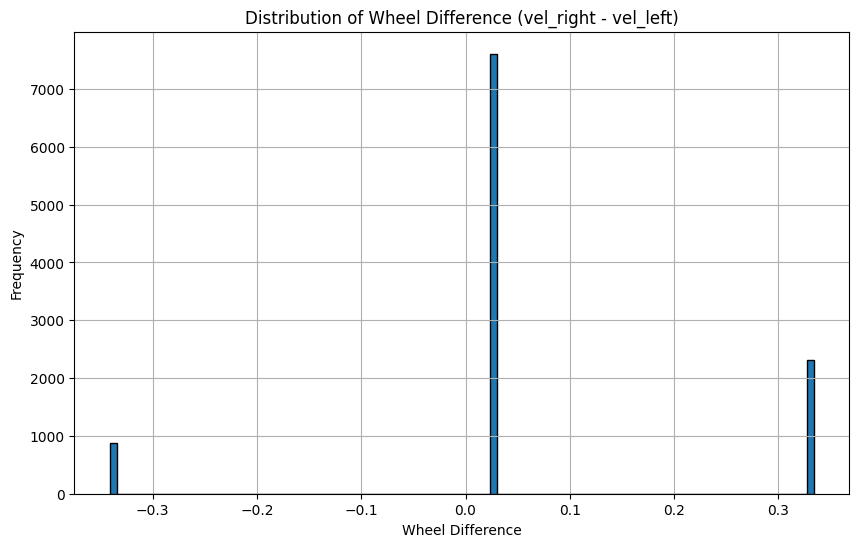


Descriptive statistics for 'wheel_diff':
count    10809.000000
mean         0.060993
std          0.173689
min         -0.341253
25%          0.024458
50%          0.024458
75%          0.024458
max          0.334265


In [5]:
import matplotlib.pyplot as plt

if 'df' in locals() and not df.empty:
    if 'vel_right' in df.columns and 'vel_left' in df.columns:
        df['wheel_diff'] = df['vel_right'] - df['vel_left']
        print("Added 'wheel_diff' column to DataFrame.")

        # Plotting the distribution of 'wheel_diff'
        plt.figure(figsize=(10, 6))
        plt.hist(df['wheel_diff'], bins=100, edgecolor='black')
        plt.title('Distribution of Wheel Difference (vel_right - vel_left)')
        plt.xlabel('Wheel Difference')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()

        print("\nDescriptive statistics for 'wheel_diff':")
        print(df['wheel_diff'].describe().to_string())
    else:
        print("Error: 'vel_right' or 'vel_left' columns not found in the DataFrame.")
else:
    print("DataFrame not loaded or is empty. Cannot calculate or plot 'wheel_diff'.")

In [6]:
if 'df' in locals() and not df.empty:
    if 'intent' in df.columns:
        print("\nOccurrences of each 'intent' value (in %):")
        intend_counts = df['intent'].value_counts(normalize=True) * 100
        print(intend_counts.to_string())
    else:
        print("Column 'intent' not found in the CSV.")
else:
    print("DataFrame not loaded or is empty. Cannot analyze 'intend' column.")


Occurrences of each 'intent' value (in %):
intent
lane_following    73.022481
left              10.519012
straight          10.361736
right              6.096771


In [7]:
if 'df' in locals() and not df.empty:
    control_columns = ['w', 'a', 's', 'd']
    print("\nPercentage of '1's in control columns (w, a, s, d):")
    for col in control_columns:
        if col in df.columns:
            # Assuming 0/1 binary values
            if df[col].isin([0, 1]).all():
                one_percentage = (df[col].sum() / len(df)) * 100
                print(f"  {col}: {one_percentage:.2f}%")
            else:
                print(f"  Warning: Column '{col}' contains values other than 0 or 1. Summing all non-zero values.")
                one_percentage = (df[col] != 0).sum() / len(df) * 100
                print(f"  {col}: {one_percentage:.2f}% (non-zero)")
        else:
            print(f"  Column '{col}' not found in the CSV.")
else:
    print("DataFrame not loaded or is empty. Cannot analyze control columns.")


Percentage of '1's in control columns (w, a, s, d):
  w: 100.00%
  a: 21.50%
  s: 0.00%
  d: 8.18%


## inspect segModel

In [9]:
import torchvision.transforms as transforms
import os

# Ensure YOLO is imported from ultralytics
try:
    from ultralytics import YOLO
except ImportError:
    print("ultralytics not found. Installing...")
    !pip install ultralytics
    from ultralytics import YOLO

# Preprocessing Constants
CROP_TOP_ROWS = 175
INPUT_SHAPE = (112, 224) # Height, Width

# Intent mapping for one-hot encoding
INTENT_MAP = {
    "straight": [1.0, 0.0, 0.0, 0.0],
    "left":     [0.0, 1.0, 0.0, 0.0],
    "right":    [0.0, 0.0, 1.0, 0.0],
    "lane_following":     [0.0, 0.0, 0.0, 1.0]
}

def crop_image(pil_image):
    width, height = pil_image.size
    # Ensure cropping does not result in negative height
    crop_height = height - CROP_TOP_ROWS
    if crop_height <= 0:
        # If the image is too short, just return it or handle as an error
        print(f"Warning: Image height {height} is too small for CROP_TOP_ROWS {CROP_TOP_ROWS}. Not cropping.")
        return pil_image
    return pil_image.crop((0, CROP_TOP_ROWS, width, height))

# Transforms for segmentation masks (including slight lighting augmentation for training)
def get_train_mask_transforms():
    return transforms.Compose([
        transforms.Resize(INPUT_SHAPE, interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(), # Converts PIL to FloatTensor and scales to [0.0, 1.0]
    ])

def get_eval_mask_transforms():
    return transforms.Compose([
        transforms.Resize(INPUT_SHAPE, interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(), # Converts PIL to FloatTensor and scales to [0.0, 1.0]
    ])

def get_yolo_model(model_folder: str):
    """
    Loads the YOLO segmentation model from the specified folder.
    Includes fallback logic for common YOLO model names.
    """
    seg_model_filename = '/content/yolo_best_256x320.pt'
    seg_model_path = os.path.join(model_folder, seg_model_filename)

    if not os.path.exists(seg_model_path):
        # Fallback to common YOLO saved model names
        fallback_paths = [
            os.path.join(model_folder, 'best.pt'),
            os.path.join(model_folder, 'last.pt'),
        ]
        found_fallback = False
        for fp in fallback_paths:
            if os.path.exists(fp):
                seg_model_path = fp
                seg_model_filename = os.path.basename(fp)
                print(f"Using fallback YOLO model: {seg_model_path}")
                found_fallback = True
                break

        if not found_fallback:
            raise FileNotFoundError(f"No YOLO segmentation model found at {seg_model_path} or common fallback paths in {model_folder}.")

    print(f"Loading YOLO segmentation model from: {seg_model_path}")
    model = YOLO(seg_model_path) # Load as YOLO object
    model.eval() # Set to evaluation mode to freeze weights and disable dropout/batchnorm updates
    return model

Loading segmentation model from: /content/yolo_best_256x320.pt
Segmentation model loaded successfully (YOLO format).
Model is running on device: cpu
Using random example image from dataset: /content/dataset2/images/1782993556.6160.jpg

0: 160x320 28.8ms
Speed: 0.7ms preprocess, 28.8ms inference, 4.1ms postprocess per image at shape (1, 3, 160, 320)

--- Segmentation Model Output Inspection ---
Original input image size (PIL): (640, 480) (Width, Height)
Cropped image size (PIL): (640, 305) (Width, Height)
Model output type (semantic_mask.data): <class 'torch.Tensor'>
Model output shape (semantic_mask.data): torch.Size([305, 640]) (Batch, Height, Width)
Model output device (semantic_mask.data): cuda:0
Model output data type (semantic_mask.data): torch.uint8
Unique values in predicted mask (on CPU): [0 1 2 3]


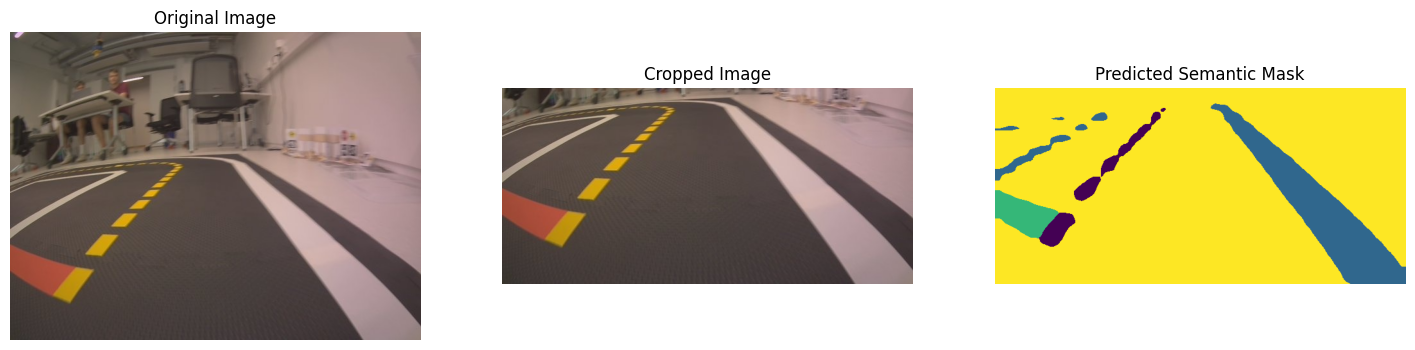

In [10]:
import os
import torch
from PIL import Image
import numpy as np
import random
import glob

# Ensure ultralytics is installed for YOLO model operations
try:
    from ultralytics import YOLO
except ImportError:
    print("ultralytics not found. Installing...")
    !pip install ultralytics
    from ultralytics import YOLO

# Define the path to the segmentation model based on user's request
seg_model_filename = '/content/yolo_best_256x320.pt'
seg_model_path = os.path.join(this_folder, seg_model_filename)

if not os.path.exists(seg_model_path):
    print(f"Error: Segmentation model '{seg_model_filename}' not found at {seg_model_path}.")
    print("Attempting to find 'best.pt' or 'last.pt' from a YOLO training run in 'this_folder'.")

    # Fallback to common YOLO saved model names
    fallback_paths = [
        os.path.join(this_folder, 'best.pt'),
        os.path.join(this_folder, 'last.pt'),
        # If the user trained a YOLO model, it might be in a 'runs' directory
        # This assumes a specific run name, which might not always be accurate
        # os.path.join(this_folder, 'runs', 'lane_marking_segmentation', 'weights', 'best.pt'),
        # os.path.join(this_folder, 'runs', 'lane_marking_segmentation', 'weights', 'last.pt'),
    ]
    found_fallback = False
    for fp in fallback_paths:
        if os.path.exists(fp):
            seg_model_path = fp
            seg_model_filename = os.path.basename(fp)
            print(f"Found fallback model: {seg_model_path}")
            found_fallback = True
            break

    if not found_fallback:
        raise FileNotFoundError(f"No segmentation model found at {seg_model_path} or common fallback paths. Please ensure your model is correctly saved and named.")

print(f"Loading segmentation model from: {seg_model_path}")

try:
    # Load the YOLO model
    model = YOLO(seg_model_path, task = "semantic")
    print("Segmentation model loaded successfully (YOLO format).")
    print(f"Model is running on device: {model.device}")

    # Prepare an example image for inference
    original_full_img = None # Store the original uncropped image
    if 'images_dir' in globals() and os.path.exists(images_dir):
        # Check if images_dir actually contains image files
        image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            random_image_path = os.path.join(images_dir, random.choice(image_files))
            print(f"Using random example image from dataset: {random_image_path}")
            original_full_img = Image.open(random_image_path).convert('RGB')
        else:
            print(f"No image files found in '{images_dir}'. Creating a dummy image.")

    if original_full_img is None:
        # From user context, imgsz=(480,640) was used for training (height, width)
        dummy_height, dummy_width = 480, 640
        print(f"Creating a dummy {dummy_width}x{dummy_height} RGB image for inference.")
        original_full_img = Image.new('RGB', (dummy_width, dummy_height), color='red') # PIL Image expects (width, height)

    # Make a copy of the original image for display after cropping
    cropped_img_for_display = crop_image(original_full_img.copy())
    # The example_img for inference is the cropped one
    example_img = cropped_img_for_display

    # Perform inference
    results = model(example_img) # YOLO model handles resizing internally

    # Inspect the outputs if semantic_mask is present
    if results and hasattr(results[0], 'semantic_mask'):
        predicted_mask = results[0].semantic_mask.data # This is typically a torch.Tensor
        predicted_mask_numpy = predicted_mask.cpu().numpy()

        print(f"\n--- Segmentation Model Output Inspection ---")
        print(f"Original input image size (PIL): {original_full_img.size} (Width, Height)")
        print(f"Cropped image size (PIL): {example_img.size} (Width, Height)")
        print(f"Model output type (semantic_mask.data): {type(predicted_mask)}")
        print(f"Model output shape (semantic_mask.data): {predicted_mask.shape} (Batch, Height, Width)")
        print(f"Model output device (semantic_mask.data): {predicted_mask.device}")
        print(f"Model output data type (semantic_mask.data): {predicted_mask.dtype}")
        print(f"Unique values in predicted mask (on CPU): {np.unique(predicted_mask_numpy)}")

        # Basic visualization if matplotlib is available (no complex colormap assumed)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.imshow(original_full_img)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(cropped_img_for_display)
        plt.title('Cropped Image')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(predicted_mask_numpy)
        plt.title('Predicted Semantic Mask')
        plt.axis('off')
        plt.show()

    elif results:
        print("\nModel produced results, but 'semantic_mask' attribute was not found in the first result object.")
        print(f"Available attributes on results[0]: {[attr for attr in dir(results[0]) if not attr.startswith('__')]}")
        print("This might happen if the YOLO model was not specifically trained for segmentation or if the output format is different than expected.")
    else:
        print("Model inference returned no results.")

except Exception as e:
    print(f"An error occurred during model loading or inference: {e}")
    print("Please ensure ultralytics is installed and the model file is a valid YOLO segmentation model. Also check if the model architecture is compatible.")

## Training

### PilotNet Model

In [16]:
import torch
import torch.nn as nn

class ConditionalPilotNet(nn.Module):
    def __init__(self):
        super(ConditionalPilotNet, self).__init__()

        # Modified to accept 1 input channel (segmentation mask)
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=5, stride=2), nn.BatchNorm2d(24), nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2), nn.BatchNorm2d(36), nn.ReLU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2), nn.BatchNorm2d(48), nn.ReLU(),
            nn.Conv2d(48, 48, kernel_size=3, stride=1), nn.BatchNorm2d(48), nn.ReLU(),
            nn.Conv2d(48, 48, kernel_size=3, stride=1), nn.BatchNorm2d(48), nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((5, 10))
        # Adjusted flattened_size based on expected output after pooling
        self.flattened_size = 48 * 5 * 10 # 3200

        # Define three separate regression heads for 'straight', 'left', 'right'
        # Each head takes only the image features (flattened_size) as input
        # Using the specified smaller head architecture
        self.straight_head = nn.Sequential(
            nn.Linear(self.flattened_size, 50),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2) # Output 2 velocities as clarified
        )
        self.left_head = nn.Sequential(
            nn.Linear(self.flattened_size, 50),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2) # Output 2 velocities as clarified
        )
        self.right_head = nn.Sequential(
            nn.Linear(self.flattened_size, 50),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2) # Output 2 velocities as clarified
        )
        self.lane_following_head = nn.Sequential(
            nn.Linear(self.flattened_size, 50),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2) # Output 2 velocities as clarified
        )

    def forward(self, img, intent):
        # img is now expected to be the processed segmentation mask (1-channel tensor)
        features = self.feature_extractor(img)
        features = self.pool(features)
        features = features.reshape(-1, self.flattened_size) # [batch_size, flattened_size]

        # Determine which intent is active for each sample in the batch
        # intent is one-hot encoded: [straight, left, right, lane_following]
        intent_indices = torch.argmax(intent, dim=1) # E.g., [0, 1, 0, 2, 3, ...] for batch_size samples

        # Initialize an output tensor of zeros
        batch_size = features.shape[0]
        output_velocities = torch.zeros(batch_size, 2, device=img.device)

        # Create masks for each intent (assuming order: Straight=0, Left=1, Right=2, Lane_following=3)
        is_straight = (intent_indices == 0)
        is_left = (intent_indices == 1)
        is_right = (intent_indices == 2)
        is_lane_following = (intent_indices == 3)

        # Apply the corresponding head based on intent for each sample
        if is_straight.any():
            output_velocities[is_straight] = self.straight_head(features[is_straight])
        if is_left.any():
            output_velocities[is_left] = self.left_head(features[is_left])
        if is_right.any():
            output_velocities[is_right] = self.right_head(features[is_right])
        if is_lane_following.any(): # Add this block for lane_following
            output_velocities[is_lane_following] = self.lane_following_head(features[is_lane_following])

        return output_velocities

In [12]:
# Count trainable parameters in the model
if 'ConditionalPilotNet' in locals():
    model_instance = ConditionalPilotNet()
    total_params = sum(p.numel() for p in model_instance.parameters() if p.requires_grad)
    print(f"Total trainable parameters in ConditionalPilotNet: {total_params}")
else:
    print("ConditionalPilotNet class not found. Please ensure it is defined before counting parameters.")

Total trainable parameters in ConditionalPilotNet: 589876


### Dataset

In [13]:
import os
import random
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as TF
import pandas as pd

# Assumes ConditionalPilotNet, get_train_mask_transforms, get_eval_mask_transforms, crop_image, INTENT_MAP are defined above

class DuckieTownDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, yolo_model=None, oversample_train_classes=False):
        self.image_dir = image_dir
        self.transform = transform
        self.yolo_model = yolo_model

        if self.yolo_model is None:
            raise ValueError("YOLO segmentation model must be provided to the DuckieTownDataset.")
        self.yolo_model.eval()

        if oversample_train_classes:
            print("Applying custom intent oversampling (40% LF, 20% L, 20% S, 20% R)...")

            # Target percentages
            targets = {
                'lane_following': 0.40,
                'left': 0.20,
                'straight': 0.20,
                'right': 0.20
            }

            # Group by intent
            groups = {intent: dataframe[dataframe['intent'] == intent] for intent in targets.keys()}

            # Determine size based on the most over-represented class (lane_following usually)
            # To ensure we don't lose data, we scale based on the largest group relative to its target
            current_counts = dataframe['intent'].value_counts()
            max_needed = 0
            for intent, target_pct in targets.items():
                if intent in current_counts:
                    # How many total samples would we need if this class was the bottleneck?
                    needed_total = current_counts[intent] / target_pct
                    max_needed = max(max_needed, needed_total)

            # Use a reasonable total size (e.g., keeping at least the original count or scaling up)
            total_size = int(max(len(dataframe), max_needed))

            balanced_frames = []
            for intent, target_pct in targets.items():
                n_samples = int(total_size * target_pct)
                if n_samples > 0:
                    group_df = groups[intent]
                    if len(group_df) == 0:
                        print(f"Warning: No samples found for intent '{intent}'.")
                        continue
                    # Resample with replacement to hit the specific percentage
                    resampled = group_df.sample(n=n_samples, replace=True, random_state=42)
                    balanced_frames.append(resampled)

            self.dataframe = pd.concat(balanced_frames).sample(frac=1, random_state=42).reset_index(drop=True)
            print(f"Oversampling complete. New dataset size: {len(self.dataframe)}")
            print("New intent distribution (%):")
            print(self.dataframe['intent'].value_counts(normalize=True) * 100)
        else:
            self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        raw_img_name = os.path.join(self.image_dir, self.dataframe.iloc[idx]['image_filename'])
        raw_image = Image.open(raw_img_name).convert('RGB')

        with torch.no_grad():
            yolo_results = self.yolo_model(raw_image, verbose=False)

        if not yolo_results or not hasattr(yolo_results[0], 'semantic_mask'):
            yolo_output_h, yolo_output_w = 480, 640
            segmentation_mask_tensor = torch.zeros(yolo_output_h, yolo_output_w, dtype=torch.uint8)
        else:
            segmentation_mask_tensor = yolo_results[0].semantic_mask.data.cpu()

        mask_pil = Image.fromarray(segmentation_mask_tensor.numpy())

        vel_left = self.dataframe.iloc[idx]['vel_left']
        vel_right = self.dataframe.iloc[idx]['vel_right']
        intent_str = self.dataframe.iloc[idx]['intent']

        target_vel = torch.tensor([vel_left, vel_right], dtype=torch.float32)
        intent_tensor = torch.tensor(INTENT_MAP.get(intent_str, [1.0, 0.0, 0.0, 0.0]), dtype=torch.float32)

        cropped_mask_pil = crop_image(mask_pil)

        # Horizontal Flip logic
        if self.transform == get_train_mask_transforms() and random.random() > 0.5:
            cropped_mask_pil = TF.hflip(cropped_mask_pil)
            target_vel = torch.tensor([vel_right, vel_left], dtype=torch.float32)
            if intent_str == "left": intent_str = "right"
            elif intent_str == "right": intent_str = "left"
            intent_tensor = torch.tensor(INTENT_MAP.get(intent_str, [1.0, 0.0, 0.0, 0.0]), dtype=torch.float32)

        if self.transform:
            processed_mask_tensor = self.transform(cropped_mask_pil)
        else:
            processed_mask_tensor = transforms.ToTensor()(cropped_mask_pil)

        return processed_mask_tensor, intent_tensor, target_vel

### Training Script

In [19]:
import os
import time
import torch
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.multiprocessing as mp
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# Assumes ConditionalPilotNet, DuckieTownDataset, get_train_mask_transforms, get_eval_mask_transforms, get_yolo_model are defined above

def train_model(data_path, epochs=10, batch_size=64, learning_rate=0.001):
    """Handles Data Loading, Training, Validation, and Saving PyTorch weights,
    and returns training/validation losses for plotting.

    The ConditionalPilotNet is now trained on segmentation masks from a frozen YOLO model.
    """
    # Set the multiprocessing start method to 'spawn' for CUDA compatibility
    try:
        mp.set_start_method('spawn', force=True)
    except RuntimeError:
        pass # Already set

    images_folder = os.path.join(data_path, 'images')
    logs_filepath = os.path.join(data_path, 'log.csv')

    print("Loading dataset...")
    logs_df = pd.read_csv(logs_filepath)
    train_df, val_df = train_test_split(logs_df, test_size=0.2, random_state=42)
    print(f"Training set: {len(train_df)} | Validation set: {len(val_df)}")

    # Load and freeze the YOLO segmentation model once
    global this_folder
    yolo_seg_model = get_yolo_model(this_folder)
    yolo_seg_model.eval()
    print("YOLO segmentation model loaded and frozen for feature extraction.")

    train_dataset = DuckieTownDataset(
        train_df, images_folder, transform=get_train_mask_transforms(), yolo_model=yolo_seg_model
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    val_dataset = DuckieTownDataset(
        val_df, images_folder, transform=get_eval_mask_transforms(), yolo_model=yolo_seg_model
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalPilotNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.MSELoss()

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses = []
    val_losses = []

    model.eval()
    initial_val_loss = 0.0
    with torch.no_grad():
        for images, intents, targets in val_loader:
            images, intents, targets = images.to(device), intents.to(device), targets.to(device)
            outputs = model(images, intents)
            loss = criterion(outputs, targets)
            initial_val_loss += loss.item() * images.size(0)
    initial_val_loss /= len(val_loader.dataset)
    val_losses.append(initial_val_loss)
    print(f"Initial Validation Loss: {initial_val_loss:.4f}")

    print(f"Training Started on device: {device}...")
    best_val_loss = float('inf')

    os.makedirs(this_folder, exist_ok=True)
    best_pth_path = os.path.join(this_folder, "best_reg_model.pt")
    last_pth_path = os.path.join(this_folder, "last_reg_model.pt")

    try:
        for epoch in range(epochs):
            epoch_start_time = time.time()

            model.train()
            running_train_loss = 0.0
            for images, intents, targets in tqdm(train_loader):
                images, intents, targets = images.to(device), intents.to(device), targets.to(device)

                optimizer.zero_grad()
                outputs = model(images, intents)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item() * images.size(0)

            avg_train_loss = running_train_loss / len(train_loader.dataset)
            train_losses.append(avg_train_loss)

            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for images, intents, targets in val_loader:
                    images, intents, targets = images.to(device), intents.to(device), targets.to(device)
                    outputs = model(images, intents)
                    loss = criterion(outputs, targets)
                    running_val_loss += loss.item() * images.size(0)

            avg_val_loss = running_val_loss / len(val_loader.dataset)
            val_losses.append(avg_val_loss)

            scheduler.step(avg_val_loss)
            epoch_duration = time.time() - epoch_start_time
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_duration:.2f}s")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save(model.state_dict(), best_pth_path)
                print(f"   [*] New best validation loss! Saved best_model.pt to {this_folder}")

    except Exception as e:
        print(f"\nTraining encountered an error: {e}")
        print("Saving current model state...")
    finally:
        torch.save(model.state_dict(), last_pth_path)
        print(f"Process complete. Saved last_model.pt to {this_folder}")
        return train_losses, val_losses

## Training Pipeline Execution and Visualization

Loading dataset...
Training set: 8647 | Validation set: 2162
Loading YOLO segmentation model from: /content/yolo_best_256x320.pt
YOLO segmentation model loaded and frozen for feature extraction.
Initial Validation Loss: 0.0769
Training Started on device: cuda...


100%|██████████| 136/136 [01:07<00:00,  2.01it/s]


Epoch 1/100 | Train Loss: 0.0104 | Val Loss: 0.0067 | Time: 85.65s
   [*] New best validation loss! Saved best_model.pt to /content/


100%|██████████| 136/136 [01:05<00:00,  2.08it/s]


Epoch 2/100 | Train Loss: 0.0061 | Val Loss: 0.0069 | Time: 81.76s


...

Epoch 15/100 | Train Loss: 0.0038 | Val Loss: 0.0050 | Time: 92.79s


100%|██████████| 136/136 [01:14<00:00,  1.83it/s]


Epoch 16/100 | Train Loss: 0.0037 | Val Loss: 0.0040 | Time: 92.23s
   [*] New best validation loss! Saved best_model.pt to /content/


 76%|███████▌  | 103/136 [00:56<00:18,  1.83it/s]

Process complete. Saved last_model.pt to /content/


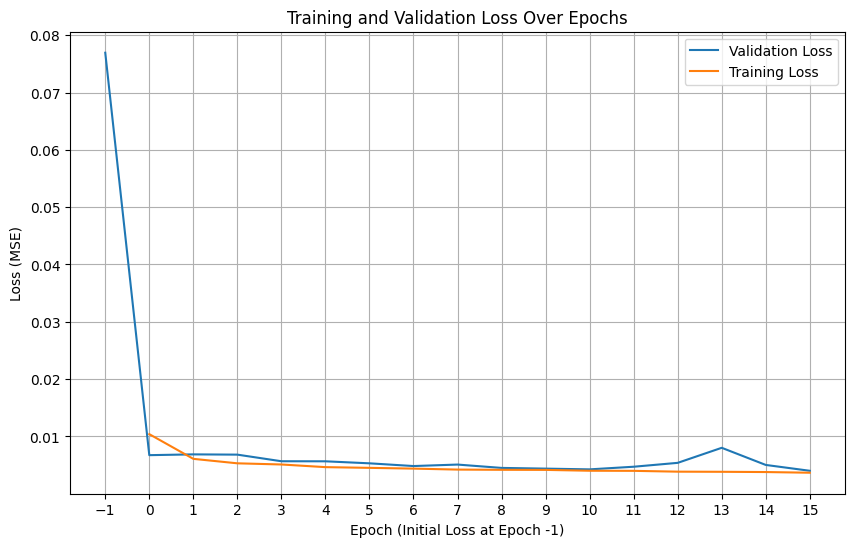

In [20]:
import matplotlib.pyplot as plt

# Call the train_model function and store the returned losses
train_losses, val_losses = train_model(data_path, epochs=100, batch_size=64, learning_rate=0.001)

# Plotting Training and Validation Loss
if 'train_losses' in locals() and 'val_losses' in locals():
    # Epochs range needs to account for the initial validation loss (epoch -1)
    epochs_range = range(-1, len(train_losses))

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, val_losses, label='Validation Loss') # Plot validation loss first to include initial loss
    plt.plot(range(len(train_losses)), train_losses, label='Training Loss') # Training loss starts from epoch 0

    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch (Initial Loss at Epoch -1)')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.xticks(epochs_range) # Ensure all epoch markers are shown
    plt.show()
else:
    print("Training and validation losses not available for plotting. Please uncomment and run `train_model` first.")

## Model Evaluation: Predictions on Example Images

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from PIL import Image
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Assumes ConditionalPilotNet, DuckieTownDataset, get_eval_mask_transforms, get_yolo_model, crop_image are defined above

# --- 1. Load ConditionalPilotNet model ---
model_path = os.path.join(this_folder, 'best_model.pth')

if not os.path.exists(model_path):
    print(f"Error: ConditionalPilotNet model not found at {model_path}. Please train the model first.")
    model = None
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalPilotNet().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # Set model to evaluation mode
    print(f"Loaded ConditionalPilotNet from {model_path}")

# --- 2. Load YOLO Segmentation Model ---
yolo_seg_model = None
try:
    yolo_seg_model = get_yolo_model(this_folder)
    yolo_seg_model.eval()
    print("YOLO segmentation model loaded for feature extraction.")
except FileNotFoundError as e:
    print(f"Error loading YOLO model: {e}")


if model and yolo_seg_model:
    # --- 3. Prepare a validation dataset and loader ---
    images_folder = os.path.join(data_path, 'images')
    logs_filepath = os.path.join(data_path, 'log.csv')
    logs_df = pd.read_csv(logs_filepath)
    _, val_df = train_test_split(logs_df, test_size=0.2, random_state=42)

    # Instantiate DuckieTownDataset with the YOLO model
    val_dataset = DuckieTownDataset(val_df, images_folder, transform=get_eval_mask_transforms(), yolo_model=yolo_seg_model)

    print("Displaying predictions for 10 random validation images:")

    # Select 10 random indices from the validation set
    random_indices = random.sample(range(len(val_dataset)), 10)

    fig, axes = plt.subplots(10, 2, figsize=(15, 40))
    fig.suptitle('Model Predictions vs. Ground Truth (Validation Set)', y=1.02)

    with torch.no_grad():
        for i, idx in enumerate(random_indices):
            # The `image` from val_dataset is now the processed segmentation mask tensor
            processed_mask_tensor, intent_tensor, target_vel = val_dataset[idx]

            # Load original raw image for display (before any processing)
            original_img_filename = val_dataset.dataframe.iloc[idx]['image_filename']
            original_img_path = os.path.join(val_dataset.image_dir, original_img_filename)
            original_raw_pil_image = Image.open(original_img_path).convert('RGB')

            # Optionally, get the intermediate cropped mask for visualization
            with torch.no_grad():
                yolo_results_vis = yolo_seg_model(original_raw_pil_image, verbose=False)
            intermediate_mask_tensor = yolo_results_vis[0].semantic_mask.data.cpu() # [H, W], uint8
            intermediate_mask_pil = crop_image(Image.fromarray(intermediate_mask_tensor.numpy()))


            # Add batch dimension and move to device for ConditionalPilotNet input
            image_input = processed_mask_tensor.unsqueeze(0).to(device) # [1, 1, H, W]
            intent_input = intent_tensor.unsqueeze(0).to(device) # [1, 4]

            # Make prediction
            output_vel = model(image_input, intent_input).cpu().numpy().flatten()

            # Ground Truth
            gt_vel = target_vel.cpu().numpy()

            # Calculate error
            error = np.abs(output_vel - gt_vel)

            # Display
            ax0 = axes[i, 0]
            ax0.imshow(original_raw_pil_image)
            ax0.set_title(f"Raw Input Image: {original_img_filename}\nIntent: {val_dataset.dataframe.iloc[idx]['intent']}", fontsize=8)
            ax0.axis('off')

            ax1 = axes[i, 1]
            ax1.imshow(intermediate_mask_pil) # Display the cropped YOLO mask for context
            ax1.set_title(
                f"Cropped Mask\nGT: L={gt_vel[0]:.4f}, R={gt_vel[1]:.4f}\nPred: L={output_vel[0]:.4f}, R={output_vel[1]:.4f}\nError: L={error[0]:.4f}, R={error[1]:.4f}", fontsize=8
            )
            ax1.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Skipping model evaluation due to missing ConditionalPilotNet or YOLO model.")


NameError: name 'this_folder' is not defined

### Export Script

In [ ]:
import os
import torch

# Assumes ConditionalPilotNet is defined above

def compile_to_onnx(model_folder):
    """Loads saved PyTorch weights and exports them to ONNX format.
    Adjusted for 1-channel segmentation mask input.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalPilotNet().to(device)
    model.eval() # Ensure dropout layers are disabled for export

    # Define exact dummy inputs expected by the model for 1-channel mask
    dummy_img = torch.randn(1, 1, INPUT_SHAPE[0], INPUT_SHAPE[1]).to(device) # [1, 1, Height, Width]
    dummy_intent = torch.randn(1, 4).to(device)

    # Compile Best Model
    best_pth = os.path.join(model_folder, "best_model.pth")
    if os.path.exists(best_pth):
        try:
            model.load_state_dict(torch.load(best_pth, map_location=device))
            torch.onnx.export(
                model, (dummy_img, dummy_intent), os.path.join(model_folder, "best_model.onnx"),
                export_params=True, opset_version=11, # Use opset 11 as previously requested implicitly
                input_names=['image_input', 'intent_input'], output_names=['wheel_velocities'],
                dynamic_axes={'image_input': {0: 'batch_size'}, 'intent_input': {0: 'batch_size'}, 'wheel_velocities': {0: 'batch_size'}} # Add dynamic axes for batch size
            )
            print(f"SUCCESS: Exported best_model.onnx to {model_folder}")
        except Exception as e:
            print(f"Error exporting best_model.onnx: {e}")

    # Compile Last Model
    last_pth = os.path.join(model_folder, "last_model.pth")
    if os.path.exists(last_pth):
        try:
            model.load_state_dict(torch.load(last_pth, map_location=device))
            torch.onnx.export(
                model, (dummy_img, dummy_intent), os.path.join(model_folder, "last_model.onnx"),
                export_params=True, opset_version=11, # Use opset 11 as previously requested implicitly
                input_names=['image_input', 'intent_input'], output_names=['wheel_velocities'],
                dynamic_axes={'image_input': {0: 'batch_size'}, 'intent_input': {0: 'batch_size'}, 'wheel_velocities': {0: 'batch_size'}} # Add dynamic axes for batch size
            )
            print(f"SUCCESS: Exported last_model.onnx to {model_folder}")
        except Exception as e:
            print(f"Error exporting last_model.onnx: {e}")


In [ ]:
!pip install onnxscript
compile_to_onnx(this_folder)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 151.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 23.0 MB/s eta 0:00:00
